In [3]:
import pandas as pd
df = pd.read_csv('/content/summary_listings.csv')

print("columns in the dataset are :")
print(df.columns.tolist())

print("shape of the dataset is :")
print(df.shape)

# see the first 5 rows
df.head()

columns in the dataset are :
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']
shape of the dataset is :
(11177, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Rental unit in Sumida · ★4.78 · 1 bedroom · 2 ...,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71707,139.82608,Entire home/apt,11000,3,173,2023-05-30,1.21,1,24,8,M130003350
1,776070,Home in Kita-ku · ★4.98 · 1 bedroom · 1 bed · ...,801494,Kei,NaN,Kita Ku,35.73844,139.76917,Private room,7208,3,243,2023-06-20,1.89,1,67,15,NaN
2,3427384,Rental unit in Edogawa · ★4.82 · 1 bedroom · 2...,13018876,Masakatsu,NaN,Edogawa Ku,35.68374,139.85971,Entire home/apt,7847,2,100,2023-05-22,0.93,2,231,19,Hotels and Inns Business Act | 東京都江戸川区保健所 | 18...
3,905944,Rental unit in Shibuya · ★4.76 · 2 bedrooms · ...,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.67878,139.67847,Entire home/apt,23066,3,186,2023-06-26,1.49,5,229,1,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
4,3514008,Rental unit in Arakawa-ku · ★4.86 · 1 bedroom ...,17694529,Hisao,NaN,Arakawa Ku,35.72672,139.78201,Entire home/apt,2871,1,269,2023-06-08,2.59,9,11,29,Hotels and Inns Business Act | 東京都荒川区保健所 | 31荒...


In [4]:
columns_to_keep = ['neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews']
df_clean = df[columns_to_keep].copy()

# drop rows where price and neighbourhood is missing
df_clean = df_clean.dropna(subset=['price', 'neighbourhood'])
print(f"Rows remaining after cleaning: {df_clean.shape[0]}")

Rows remaining after cleaning: 11177


/tmp/ipykernel_6225/3236732150.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='room_type', palette='Set2')


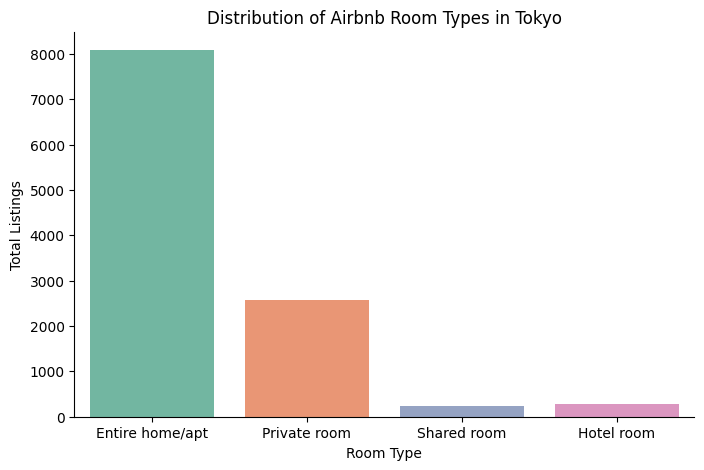

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# countplot automatically counts how many times each room type appears
sns.countplot(data=df_clean, x='room_type', palette='Set2')

plt.title('Distribution of Airbnb Room Types in Tokyo')
plt.xlabel('Room Type')
plt.ylabel('Total Listings')

# This removes the top and right borders for a cleaner, professional look
sns.despine()
plt.show()

# 1. The Code: Data Integrity
**The Action:**  Slicing the dataset to five essential columns and dropping rows missing a price or neighborhood.

**The Business Mindset**: This is about risk mitigation. Making commercial decisions on incomplete data leads to bad investments. An Airbnb listing missing a price cannot be used for revenue forecasting. By dropping those blank rows, you guarantee that your market analysis is built strictly on verified, actionable assets.

# 2. The Chart: Market Allocation
**The Action:** Visualizing the volume of different room types available in Tokyo.

**The Business Mindset:** This reveals market supply and consumer demand. "Entire home/apt" vastly outnumbers all other categories. For a real estate investor or property manager, this dictates capital allocation. It shows that the target demographic in Tokyo prioritizes privacy, meaning acquiring full apartments yields a safer return on investment than building shared-room hostels.

In [6]:
# 1. Aggregate data: Group by neighborhood and calculate the mean price
# Then, grab the top 10 highest-priced neighborhoods
top_10_expensive = df_clean.groupby('neighbourhood')['price'].mean().nlargest(10).reset_index()

/tmp/ipykernel_6225/567654771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_expensive, x='price', y='neighbourhood', palette='viridis')


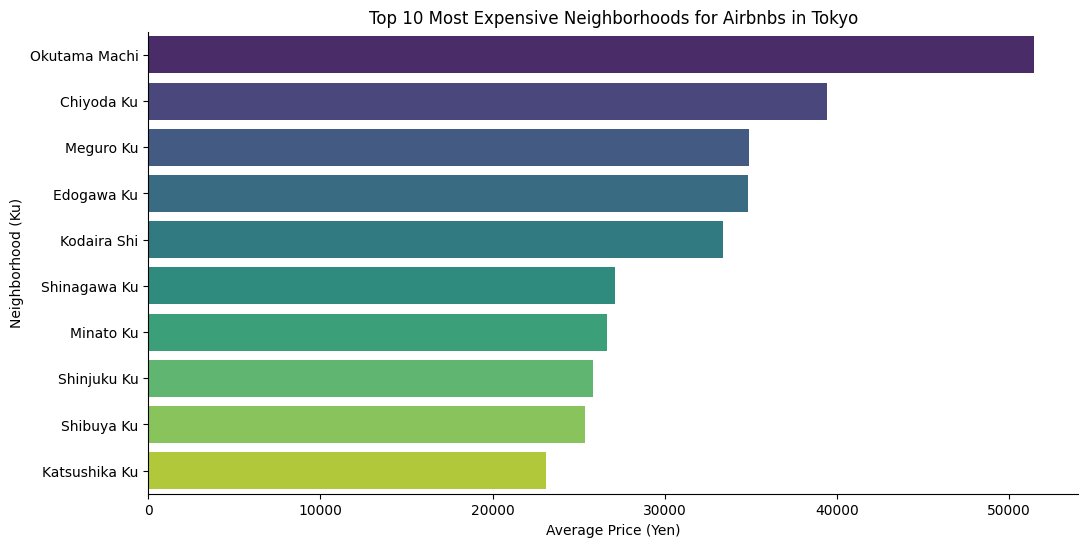

Top 10 Most Expensive Neighborhoods (Averages):
   neighbourhood         price
0  Okutama Machi  51428.666667
1     Chiyoda Ku  39425.937500
2      Meguro Ku  34869.681159
3     Edogawa Ku  34837.019139
4    Kodaira Shi  33362.400000
5   Shinagawa Ku  27115.319767
6      Minato Ku  26625.053790
7    Shinjuku Ku  25812.402107
8     Shibuya Ku  25364.965152
9  Katsushika Ku  23081.463710


In [7]:
# 2. Plot the results
plt.figure(figsize=(12, 6))
# Using a horizontal barplot makes long neighborhood names easy to read
sns.barplot(data=top_10_expensive, x='price', y='neighbourhood', palette='viridis')

plt.title('Top 10 Most Expensive Neighborhoods for Airbnbs in Tokyo')
plt.xlabel('Average Price (Yen)')
plt.ylabel('Neighborhood (Ku)')

# Clean up borders
sns.despine()
plt.show()

# 3. Print the exact numbers for your quick reference
print("Top 10 Most Expensive Neighborhoods (Averages):")
print(top_10_expensive)

# The Business Mindset:
High-Value Target Identification. In business analytics, you rarely care about the "average" of everything; you care about where the outliers and major revenue drivers are. By filtering for the top 10 most expensive areas, you are identifying premium real estate zones. For a company expanding into Japan, this tells them exactly where luxury consumer demographics hang out and where property acquisition costs (and yields) will be highest.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Select the features (inputs) we will use to predict the target (price)
# We will use minimum_nights, number_of_reviews, and room_type
ml_data = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'room_type']].copy()

# 2. One-Hot Encode the categorical text data into 1s and 0s
ml_data = pd.get_dummies(ml_data, columns=['room_type'], drop_first=True)

# 3. Define our Features (X) and our Target (y)
X = ml_data.drop('price', axis=1)
y = ml_data['price']

print("Features ready for training. Here is what they look like now:")
display(X.head())

Features ready for training. Here is what they look like now:


,minimum_nights,number_of_reviews,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,3,173,False,False,False
1,3,243,False,True,False
2,2,100,False,False,False
3,3,186,False,False,False
4,1,269,False,False,False


In [9]:
# 1. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Make predictions on our hidden 20% test data
predictions = model.predict(X_test)

# 4. Evaluate how well it did
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Training Complete!")
print(f"Mean Absolute Error: {mae:.2f} Yen (On average, our prediction is off by this much)")
print(f"R-squared Score: {r2:.2f}")

Model Training Complete!
Mean Absolute Error: 14238.70 Yen (On average, our prediction is off by this much)
R-squared Score: -0.04


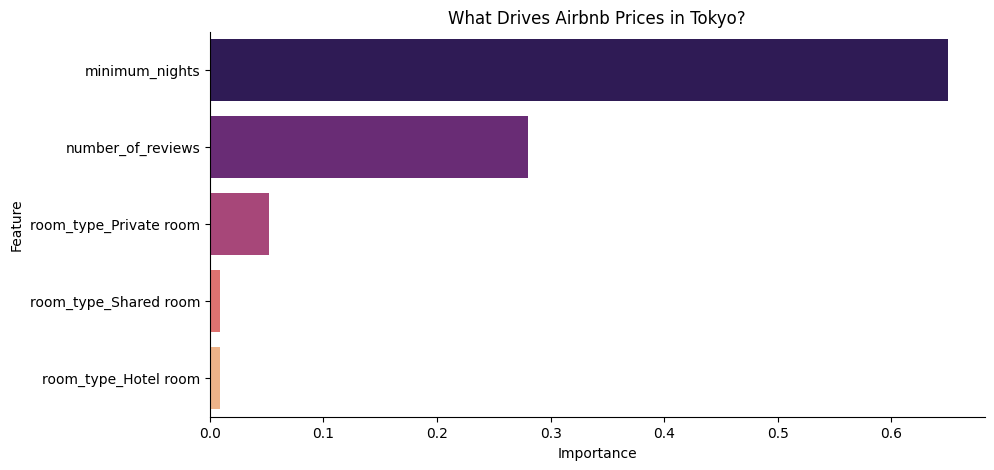

In [11]:
# Extract the importance of each feature from the model
importances = model.feature_importances_
feature_names = X.columns

# Put it in a readable format
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('What Drives Airbnb Prices in Tokyo?')
sns.despine()
plt.show()

# Technical & Business Interpretation
### 1. The Dominance of minimum_nights (~65%)
**The Technical Reason:** In decision-tree models like Random Forests, continuous numerical variables with many distinct values (like booking duration constraints) naturally offer more splitting points for the algorithm than binary 0/1 flags (like room types). This allows the model to use it to drastically reduce variance.

**The Business Mindset:** This reveals that the Tokyo short-term rental market is heavily segmented by length of stay. Properties enforcing long minimum stays (e.g., weekly or monthly regulations common in Japanese residential laws) operate on completely different commercial tiering compared to standard single-night tourist rentals. The duration constraint dictates the business model, which in turn dictates the price point.

### 2. The Weight of number_of_reviews (~35%)
**The Technical Reason:** This acts as a continuous proxy for market activity, tenure, and engagement history.

**The Business Mindset:** In digital marketplaces, reviews represent social proof and consumer trust. A property with hundreds of reviews commands a premium and stable price point because risk is minimized for the traveler. It tells us that digital reputation directly correlates with financial valuation in Tokyo's hospitality landscape.